# Non-dimensionalization
In this notebook, we compute a non-dimensionalization of the ADR PDE we believe to describe the physics of seasonal sea ice formation.  That PDE is, in particular,
$$
u_t = \nabla \cdot (\kappa \nabla u) - \nabla \cdot (v u) + f
$$
In general, we like to consider space-time varying parameterization
$$
\begin{aligned}
    \kappa: \mathbb{R}_+ \times \mathbb{R}^2 &\rightarrow \mathbb{R} \\
    v: \mathbb{R}_+ \times \mathbb{R}^2 &\rightarrow \mathbb{R}^2
\end{aligned}
$$
but the PDE is ill-posed without significant heavy lifting on the front of minimal-energy assumptions.  To remedy this, we simply consider temporally constant parameters in any time interval, i.e., 
$$
\begin{aligned}
    \kappa: \mathbb{R}^2 &\rightarrow \mathbb{R} \\
    v: \mathbb{R}^2 &\rightarrow \mathbb{R}^2.
\end{aligned}
$$
Of course, we permit these parameters to change discontinuously between intervals.  An eventual goal is to nail down the analysis such that we can consider full space-time varying parameterization.


In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np

import neuralpde


First, let's inventory our parameters:
$$
\begin{array}{c c c}
    \text{Quantity}         &\text{Symbol}      &\text{Unit} \\
    \text{Field}            &\text{u}           &[U] \\
    \text{Space}            &x,\, y             &[L] \\
    \text{Time}             &t                  &[T] \\
    \text{Diffusivity}      &\kappa             &[L^2 T^{-1}] \\
    \text{Velocity}         &v                  &[L T^{-1}] \\
    \text{Forcing}          &f                  &[U T^{-1}]
\end{array}
$$

We normalize each quantity by a characteristic scale given our problem:
$$
\begin{aligned}
    \tilde{u} &= u / u_0 \\
    \tilde{x} &= x / x_0 \\
    \tilde{y} &= y / y_0 \\
    \tilde{\kappa} &= \kappa / \kappa_0 \\
    \tilde{v} &= v / v_0 \\
    \tilde{f} &= f / f_0 \\
    \tilde{t} &= t / t_0
\end{aligned}
$$

The natural scales for these quantities, given our problem, are
$$
\begin{aligned}
    u_0 &= 1 \Longleftarrow \text{ because $u \in [0, 1]$} \\
    L_0 &= dx \text{; need to verify that this is equal to } dy \\
    \kappa_0 &\longleftarrow \text{ need to research} \\
    v_0 &\longleftarrow \text{ need to research} \\
    f_0 &\longleftarrow \text{ need to compute some scales on our data} \\
    t_0 &\longleftarrow \text{ need to decide given other quantities}
\end{aligned}
$$




#### $u_0$
This is easy:


In [2]:
u0 = 1.

#### $L_0$
Let's work on computing $L_0$.

First, we need to verify that our coordinates are monotonic and evenly spaced.

In [3]:
dx, dy = np.diff(data.x)[0], np.diff(data.y)[0]

assert np.all(np.isclose(dx, np.diff(data.x)))
assert np.all(np.isclose(dy, np.diff(data.y)))


At some places in the code (i.e., finite difference derivative approximants) we implicitly assume $dx = dy$.  We should verify that this is the case:


In [4]:
assert abs(dx) == abs(dy)


Oh good.

Well, I think the prescription of $L_0$ above makes the most sense.  Let's just use that:

In [5]:
L0 = np.abs(dx)


#### $\kappa_0$ and $v_0$
Now $\kappa_0$ and $v_0$.

After a bit of research, the characteristic velocity across the entire pole system is approximately $v_0 = 5$ cm/s.

Choosing $\kappa_0$ is much more challenging: there are no direct observations of 2-d diffusion of sea ice (of course).  Instead, we know we want a Péclet number in the "stiff" regime but close to O(1).  It turns out $\kappa_0 = 10^3$ meters-square-per-second is reasonable.  See [more about the Péclet number here](https://en.wikipedia.org/wiki/P%C3%A9clet_number).  Then,
$$
Pe_{dx} = \frac{0.05 \times 25000}{1000} = 1.25,
$$
indicating that the grid-level regime "shares" advection and diffusion, while in the pole-scale problem,
$$
Pe_x = \frac{0.05 \times 3000000}{1000} = 150,
$$
advection dominates.


In [6]:
v0 = 0.05
k0 = 1e3


#### $f_0$
Now $f_0$.

The most sensible thing I can figure to compute a forcing normalization is to compute an average concentration "speed" across all seasons.

For this notebook, I am using yearly .nc files.  Here's the plan:
1. Open each data file
    1. Compute a daily ice volume (sum over last two dimensions of ice)
    2. Delete daily file after this is extracted (it starts to use too much memory)
2. Look at ice maximum between each October and June
3. Look at ice minimum between each July and September
4. Compute speed in this window
5. Average speeds

Then be done.

Time to execute:

In [7]:
import copy
import tqdm

files = glob.glob('data/V6/*.nc')

datetimes = []
daily_ice_volumes = []
for f in tqdm.tqdm(files):
    d = neuralpde.nc.SeaIceV6([f])

    datetimes.append(copy.copy(d.date))
    daily_ice_volumes.append(
        np.nansum(d.seaice_conc, axis=(1, 2))
    )

    del d

datetimes = np.concat(datetimes)
daily_ice_volumes = np.concat(daily_ice_volumes)


100%|██████████| 48/48 [01:21<00:00,  1.70s/it]


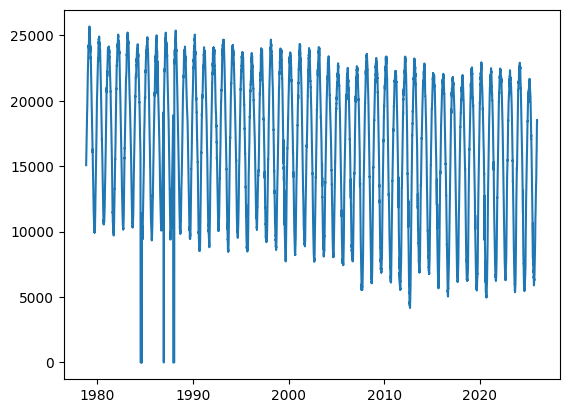

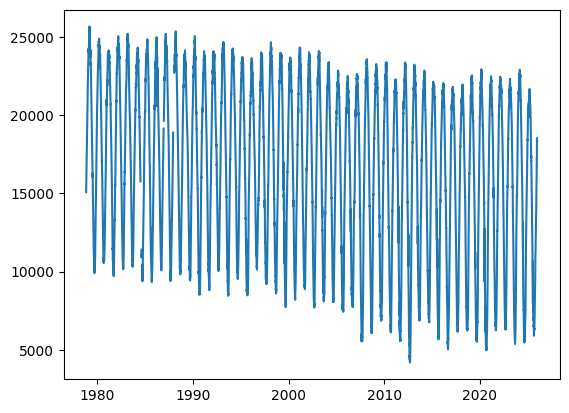

In [8]:
plt.plot(datetimes, daily_ice_volumes)
plt.show()

# do some cleaning so we avoid erroneous values
daily_ice_volumes[daily_ice_volumes < 4000] = np.nan
plt.plot(datetimes, daily_ice_volumes)
plt.show()


In [9]:
datetimes_maxes = []
datetimes_mins = []
maxes = []
mins = []
for y in range(1978, 2024):
    idx0 = np.searchsorted(datetimes, np.datetime64(f'{y}-11-01'))
    idxf = np.searchsorted(datetimes, np.datetime64(f'{y + 1}-11-01'))

    idxmax = np.nanargmax(daily_ice_volumes[idx0:idxf])
    idxmin = np.nanargmin(daily_ice_volumes[idx0:idxf])

    datetimes_maxes.append(datetimes[idxmax])
    datetimes_mins.append(datetimes[idxmin])
    maxes.append(daily_ice_volumes[idxmax])
    mins.append(daily_ice_volumes[idxmin])

datetimes_maxes = np.array(datetimes_maxes)
datetimes_mins = np.array(datetimes_mins)
maxes = np.array(maxes)
mins = np.array(mins)


In [10]:
diffs = np.concat([maxes - mins, maxes[:-1] - mins[1:]])
times = np.concat([datetimes_maxes - datetimes_mins, datetimes_maxes[:-1] - datetimes_mins[1:]])
vels = -1 * diffs / (times / np.timedelta64(1, 's'))
f0 = np.mean(vels)


#### $t_0$
Because forcing is our dominant physics, we will choose a nondimensionalization that preferences this.  In particular,
$$
t_0 = u_0 / f_0.
$$


In [11]:
t0 = u0 / f0

## Altogether Then


In [12]:
print(
    f'u0 = {1:8.4e}',
    f'L0 = {L0:8.4e}',
    f'k0 = {k0:8.4e}',
    f'v0 = {v0:8.4e}',
    f'f0 = {f0:8.4e}',
    f't0 = {t0:8.4e}',
    sep='\n'
)


u0 = 1.0000e+00
L0 = 2.5000e+04
k0 = 1.0000e+03
v0 = 5.0000e-02
f0 = 9.3949e-04
t0 = 1.0644e+03


Recall that these numbers retain their SI units and are used to convert measurements/real quantities into unitless quantities that can be fed to the solver.